<a href="https://colab.research.google.com/github/vvamsi91/HGR_Project/blob/main/HGR_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os
import argparse
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


In [24]:
import kagglehub
gti_upm_leapgestrecog_path = kagglehub.dataset_download('gti-upm/leapgestrecog')

print('Data source import complete.')

Data source import complete.


In [25]:
import os
import numpy as np
import pandas as pd

# Define the input directory
input_dir = '/kaggle/input'

# Explore the directory structure
file_list = []
for root, _, files in os.walk(input_dir):
    for file in files:
        file_path = os.path.join(root, file)
        file_list.append(file_path)

print("Images are downloaded.")

Images are downloaded.


In [26]:
class HandGestureDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        print(f"HandGestureDataset initialized with root_dir: {root_dir}")
        # Assuming subject directories are named '01', '02', ..., '10'
        valid_subjects = [f'{i:02d}' for i in range(1, 11)]
        try:
            for subject in os.listdir(root_dir):
                print(f"Listing subject: {subject}")
                if subject not in valid_subjects:
                    print(f"Skipping invalid subject: {subject}")
                    continue
                subject_path = os.path.join(root_dir, subject)
                print(f"Checking subject path: {subject_path}")
                if not os.path.isdir(subject_path):
                    print(f"Subject path is not a directory: {subject_path}")
                    continue
                for gesture in os.listdir(subject_path):
                    print(f"Listing gesture: {gesture} in subject {subject}")
                    gesture_path = os.path.join(subject_path, gesture)
                    print(f"Checking gesture path: {gesture_path}")
                    if not os.path.isdir(gesture_path):
                        print(f"Gesture path is not a directory: {gesture_path}")
                        continue
                    for img_name in os.listdir(gesture_path):
                        if img_name.endswith('.png'):
                            img_path = os.path.join(gesture_path, img_name)
                            self.samples.append((img_path, gesture))
        except FileNotFoundError as e:
            print(f"FileNotFoundError caught in HandGestureDataset: {e}")
            raise e # Re-raise the exception after printing
        self.gesture_to_idx = {g: i for i, g in enumerate(sorted(set(x[1] for x in self.samples)))}
        self.idx_to_gesture = {i: g for g, i in self.gesture_to_idx.items()}
        self.samples = [(img, self.gesture_to_idx[label]) for img, label in self.samples]
        print(f"HandGestureDataset loaded {len(self.samples)} samples.")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [32]:
class CNNLSTM(nn.Module):
    def __init__(self, num_classes, feature_dim=512, lstm_hidden=256, lstm_layers=1):
        super().__init__()
        # Use a pretrained CNN (e.g., resnet18) as feature extractor
        cnn = models.resnet18(pretrained=True)
        modules = list(cnn.children())[:-1]  # Remove the final FC layer
        self.cnn = nn.Sequential(*modules)
        self.feature_dim = feature_dim
        self.lstm = nn.LSTM(input_size=feature_dim, hidden_size=lstm_hidden, num_layers=lstm_layers, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, num_classes)

    def forward(self, x):
        # x: (batch, channels, height, width)
        batch_size = x.size(0)
        # Extract features
        features = self.cnn(x)  # (batch, feature_dim, 1, 1)
        features = features.view(batch_size, 1, self.feature_dim)  # (batch, seq_len=1, feature_dim)
        lstm_out, _ = self.lstm(features)  # (batch, seq_len, lstm_hidden)
        out = self.fc(lstm_out[:, -1, :])  # (batch, num_classes)
        return out

def plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, val_accuracies, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy over Epochs')
    plt.tight_layout()
    plt.show()

def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_labels), np.array(all_preds)

In [28]:
def main():
    import sys
    sys.argv = [sys.argv[0]] # Clear arguments passed by the Colab kernel
    parser = argparse.ArgumentParser(description='Train CNN-LSTM on Hand Gesture Dataset')
    parser.add_argument('data_dir', type=str, help='Path to the dataset root folder')
    parser.add_argument('--epochs', type=int, default=10, help='Number of training epochs')
    parser.add_argument('--batch_size', type=int, default=32, help='Batch size')
    parser.add_argument('--lr', type=float, default=1e-4, help='Learning rate')
    parser.add_argument('--num_workers', type=int, default=2, help='Number of DataLoader workers')
    parser.add_argument('--test_split', type=float, default=0.2, help='Fraction of data for test set')
    parser.add_argument('--val_split', type=float, default=0.1, help='Fraction of data for validation set')
    args = parser.parse_args()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    dataset = HandGestureDataset(args.data_dir, transform=transform)
    num_classes = len(dataset.gesture_to_idx)
    n_total = len(dataset)
    n_test = int(n_total * args.test_split)
    n_val = int(n_total * args.val_split)
    n_train = n_total - n_test - n_val
    train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
    val_loader = DataLoader(val_set, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers)
    test_loader = DataLoader(test_set, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CNNLSTM(num_classes=num_classes)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(args.epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{args.epochs} - Training'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        val_loss, val_acc, _, _ = evaluate(model, val_loader, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f'Epoch {epoch+1}: Train Loss={epoch_loss:.4f}, Train Acc={epoch_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')

    torch.save(model.state_dict(), 'hand_gesture_lstm.pth')
    print('Training complete. Model saved as hand_gesture_lstm.pth')

    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies)

    # Test and confusion matrix
    test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, device)
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    cm = confusion_matrix(test_labels, test_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[dataset.idx_to_gesture[i] for i in range(num_classes)])
    disp.plot(xticks_rotation=45)
    plt.title('Confusion Matrix (Test Set)')
    plt.show()

# if __name__ == '__main__':
#     # main('/kaggle/input/leapgestrecog/leapGestRecog/leapGestRecog')


HandGestureDataset initialized with root_dir: /kaggle/input/leapgestrecog/leapGestRecog
Listing subject: 07
Checking subject path: /kaggle/input/leapgestrecog/leapGestRecog/07
Listing gesture: 02_l in subject 07
Checking gesture path: /kaggle/input/leapgestrecog/leapGestRecog/07/02_l
Listing gesture: 04_fist_moved in subject 07
Checking gesture path: /kaggle/input/leapgestrecog/leapGestRecog/07/04_fist_moved
Listing gesture: 09_c in subject 07
Checking gesture path: /kaggle/input/leapgestrecog/leapGestRecog/07/09_c
Listing gesture: 10_down in subject 07
Checking gesture path: /kaggle/input/leapgestrecog/leapGestRecog/07/10_down
Listing gesture: 06_index in subject 07
Checking gesture path: /kaggle/input/leapgestrecog/leapGestRecog/07/06_index
Listing gesture: 08_palm_moved in subject 07
Checking gesture path: /kaggle/input/leapgestrecog/leapGestRecog/07/08_palm_moved
Listing gesture: 07_ok in subject 07
Checking gesture path: /kaggle/input/leapgestrecog/leapGestRecog/07/07_ok
Listing g

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]
Epoch 1/10 - Training: 100%|██████████| 394/394 [01:14<00:00,  5.31it/s]


Epoch 1: Train Loss=0.1880, Train Acc=0.9861, Val Loss=0.0070, Val Acc=1.0000


Epoch 2/10 - Training: 100%|██████████| 394/394 [01:03<00:00,  6.24it/s]


Epoch 2: Train Loss=0.0048, Train Acc=1.0000, Val Loss=0.0025, Val Acc=1.0000


...

Epoch 8: Train Loss=0.0003, Train Acc=1.0000, Val Loss=0.0002, Val Acc=1.0000


Epoch 9/10 - Training: 100%|██████████| 394/394 [01:03<00:00,  6.17it/s]


Epoch 9: Train Loss=0.0002, Train Acc=1.0000, Val Loss=0.0002, Val Acc=1.0000


Epoch 10/10 - Training: 100%|██████████| 394/394 [01:04<00:00,  6.12it/s]


Epoch 10: Train Loss=0.0002, Train Acc=1.0000, Val Loss=0.0001, Val Acc=1.0000
Training complete. Model saved as hand_gesture_lstm.pth


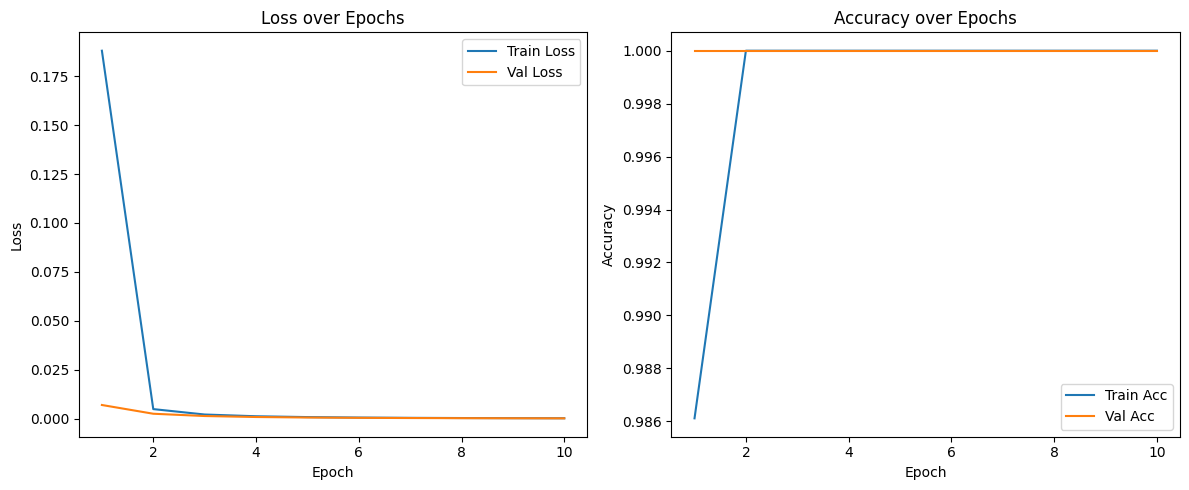

Test Loss: 0.0001, Test Accuracy: 1.0000


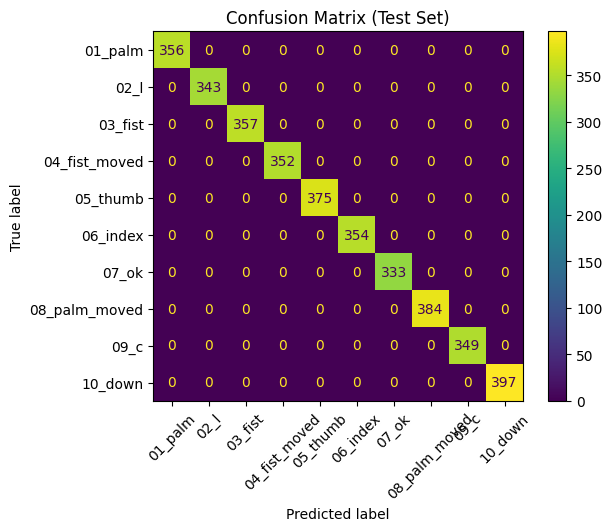

In [33]:
def main():
    # import sys
    # sys.argv = [sys.argv[0]] # Clear arguments passed by the Colab kernel
    # parser = argparse.ArgumentParser(description='Train CNN-LSTM on Hand Gesture Dataset')
    # parser.add_argument('data_dir', type=str, help='Path to the dataset root folder')
    # parser.add_argument('--epochs', type=int, default=10, help='Number of training epochs')
    # parser.add_argument('--batch_size', type=int, default=32, help='Batch size')
    # parser.add_argument('--lr', type=float, default=1e-4, help='Learning rate')
    # parser.add_argument('--num_workers', type=int, default=2, help='Number of DataLoader workers')
    # parser.add_argument('--test_split', type=float, default=0.2, help='Fraction of data for test set')
    # parser.add_split', type=float, default=0.1, help='Fraction of data for validation set')
    # args = parser.parse_args()

    data_dir = '/kaggle/input/leapgestrecog/leapGestRecog' # Hardcoded data directory
    epochs = 10
    batch_size = 32
    lr = 1e-4
    num_workers = 2
    test_split = 0.2
    val_split = 0.1


    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    dataset = HandGestureDataset(data_dir, transform=transform)
    num_classes = len(dataset.gesture_to_idx)
    n_total = len(dataset)
    n_test = int(n_total * test_split)
    n_val = int(n_total * val_split)
    n_train = n_total - n_test - n_val
    train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CNNLSTM(num_classes=num_classes)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} - Training'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        val_loss, val_acc, _, _ = evaluate(model, val_loader, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f'Epoch {epoch+1}: Train Loss={epoch_loss:.4f}, Train Acc={epoch_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')

    torch.save(model.state_dict(), 'hand_gesture_lstm.pth')
    print('Training complete. Model saved as hand_gesture_lstm.pth')

    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies)

    # Test and confusion matrix
    test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, device)
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    cm = confusion_matrix(test_labels, test_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[dataset.idx_to_gesture[i] for i in range(num_classes)])
    disp.plot(xticks_rotation=45)
    plt.title('Confusion Matrix (Test Set)')
    plt.show()

if __name__ == '__main__':
    main()